In [17]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS
/home/yuanshanwu/Documents/GitHub


In [18]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['mp4', 'custom_dicom', 'nifti', 'avi']


In [30]:
scan_type = 'nifti'

# Takes the DICOM file as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_CEUS.nii'
bmode_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_BMODE.nii'
scan_loader_kwargs = {
}

In [31]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, CEUS_scan_path, **scan_loader_kwargs)
bmode_image_data = scan_loading_step(scan_type, bmode_scan_path, **scan_loader_kwargs)

Using memory-mapped loading for 7.5 GB file
Using memory-mapped loading for 7.5 GB file


# Image Quality improvement of the B mode and CEUS iamges

In [6]:
# from src.postprocessing.napari_3d_ultrasound_viewer import simple_napari_viewer
# import napari

# viewer = simple_napari_viewer(
#     image_data=bmode_image_data,           # Your contrast data
#     seg_data=None,                   # Your segmentation data (optional)
#     frame_number=10
# )

In [32]:
bmode_image_data.pixel_data.shape

(295, 218, 219, 530)

In [34]:
from src.postprocessing.napari_3d_ultrasound_viewer import interactive_ortho_viewer
interactive_ortho_viewer(bmode_image_data.pixel_data[:, :, :, 300])

interactive(children=(IntSlider(value=147, description='Lateral (X):', max=294), IntSlider(value=109, descript…

Data shape: (295, 218, 219)
Use the sliders above to move the crosshairs!


In [35]:
from src.postprocessing.post_processing import enhance_image, denoise_ceus_wavelet
import numpy as np
# enhanced_volume = np.zeros_like(bmode_image_data.pixel_data)
# for frame in range(bmode_image_data.pixel_data.shape[3]):
clahe_image = enhance_image(bmode_image_data.pixel_data[:, :, :, 300], method='clahe', clip_limit=1.0)
final_image = enhance_image(clahe_image, method='gamma', gamma=1.2)
CEUS_image = denoise_ceus_wavelet(final_image)

In [36]:
interactive_ortho_viewer(CEUS_image)

interactive(children=(IntSlider(value=147, description='Lateral (X):', max=294), IntSlider(value=109, descript…

Data shape: (295, 218, 219)
Use the sliders above to move the crosshairs!


# Image Tuner

In [19]:
from src.postprocessing.post_processing import PyramidTunerGUI,image_tuner
# In Jupyter cell 1:
%gui qt
import sys
from PyQt6.QtWidgets import QApplication

# Initialize QApplication if needed
app = QApplication.instance()
if app is None:
    app = QApplication(sys.argv)
# image_tuner = PyramidTunerGUI(image_data.pixel_data[:, :, :, 300])
enhanced = image_tuner(image_data.pixel_data[:, :, :, 300])

Building pyramid...


NameError: name 'QSplitter' is not defined

In [ ]:
%matplotlib inline

interactive_ortho_viewer(CEUS_image)

interactive(children=(IntSlider(value=147, description='Lateral (X):', max=294), IntSlider(value=109, descript…

Data shape: (295, 218, 219)
Use the sliders above to move the crosshairs!


# Demo the CEUS Video

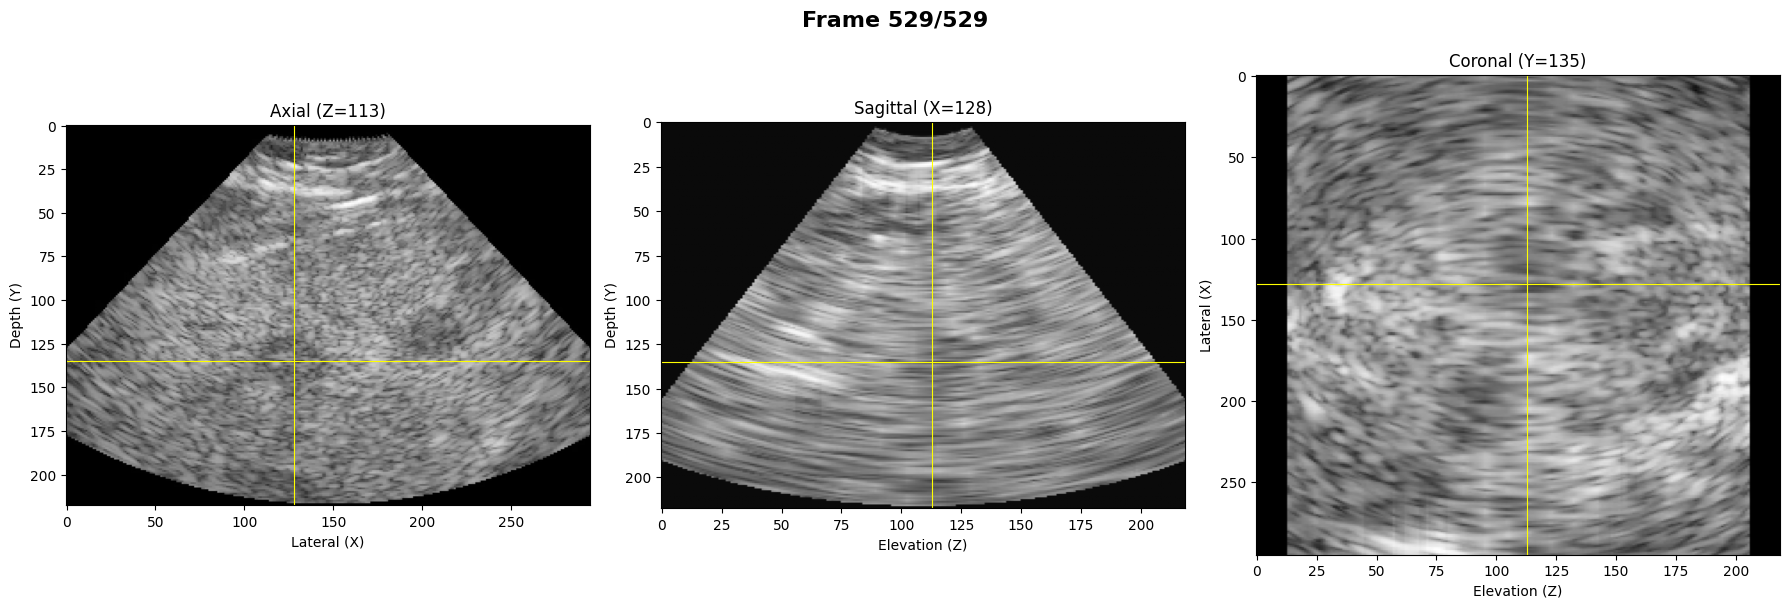

Creating GIF frames: 100%|██████████| 530/530 [07:56<00:00,  1.11it/s]

Frame 529/529


In [51]:
# Use inline backend - MORE RELIABLE for Jupyter
%matplotlib inline
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion
import imageio
from PIL import Image
import io
from tqdm import tqdm

print(f"Image shape: {bmode_image_data.pixel_data.shape}")

# Define slice positions
lateral_slice = 128   # X dimension
depth_slice = 135     # Y dimension  
elevation_slice = 113 # Z dimension

# Frame range
num_frames = bmode_image_data.pixel_data.shape[3]
start_frame = 0
end_frame = num_frames

print(f"Visualizing frames {start_frame} to {end_frame}")
print("Starting animation...\n")

frames = []

# Loop through frames
for frame in tqdm(range(start_frame, end_frame), desc="Creating GIF frames"):
    # Clear previous output and display current frame
    clear_output(wait=True)
    
    # Enhance image
    clahe_image = enhance_image(bmode_image_data.pixel_data[:, :, :, frame], method='clahe', clip_limit=1.0)
    final_image = enhance_image(clahe_image, method='gamma', gamma=1.2)
    CEUS_image = denoise_ceus_wavelet(final_image)
    
    # Create figure for this frame
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Calculate aspect ratios based on pixel dimensions
    # Aspect = (dimension_along_x_axis) / (dimension_along_y_axis)
    
    # Axial: x-axis is lateral (pixdim[0]), y-axis is depth (pixdim[1])
    aspect_axial = (bmode_image_data.pixdim[0]) / (bmode_image_data.pixdim[1]) if bmode_image_data.pixdim[0] != 0 else 1
    aspect_axial = aspect_axial * 1.8  # Scaling factor from original
    
    # Sagittal: x-axis is elevation (pixdim[2]), y-axis is depth (pixdim[1])
    aspect_sagittal = (bmode_image_data.pixdim[2]) / (bmode_image_data.pixdim[1]) if bmode_image_data.pixdim[2] != 0 else 1
    aspect_sagittal = aspect_sagittal * 1.0  # Scaling factor from original
    
    # Coronal: x-axis is elevation (pixdim[2]), y-axis is lateral (pixdim[0])
    aspect_coronal = (bmode_image_data.pixdim[2]) / (bmode_image_data.pixdim[0]) if bmode_image_data.pixdim[2] != 0 else 1
    aspect_coronal = aspect_coronal * 0.5  # Scaling factor from original
    
    # === AXIAL VIEW (X-Y plane at fixed Z) ===
    # Looking down from above - shows lateral (X) vs depth (Y)
    # Based on original: plane_ix=0, dims (0,1), needs transpose
    axial_img = np.transpose(CEUS_image[:, :, elevation_slice])
    axes[0].imshow(axial_img, cmap='gray', aspect=float(aspect_axial))
    axes[0].set_title(f'Axial (Z={elevation_slice})')
    axes[0].set_xlabel('Lateral (X)')
    axes[0].set_ylabel('Depth (Y)')
    axes[0].axvline(x=lateral_slice, color='yellow', lw=0.8)
    axes[0].axhline(y=depth_slice, color='yellow', lw=0.8)
    
    # === SAGITTAL VIEW (Z-Y plane at fixed X) ===
    # Looking from the side - shows elevation (Z) vs depth (Y)
    # Based on original: plane_ix=1, dims (2,1), NO transpose needed
    sagittal_img = CEUS_image[lateral_slice, :, :]
    axes[1].imshow(sagittal_img, cmap='gray', aspect=float(aspect_sagittal))
    axes[1].set_title(f'Sagittal (X={lateral_slice})')
    axes[1].set_xlabel('Elevation (Z)')
    axes[1].set_ylabel('Depth (Y)')
    axes[1].axvline(x=elevation_slice, color='yellow', lw=0.8)
    axes[1].axhline(y=depth_slice, color='yellow', lw=0.8)
    
    # === CORONAL VIEW (Z-X plane at fixed Y) ===
    # Looking from front/back - shows elevation (Z) vs lateral (X)
    # Based on original: plane_ix=2, dims (2,0), NO transpose needed
    coronal_img = CEUS_image[:, depth_slice, :]
    axes[2].imshow(coronal_img, cmap='gray', aspect=float(aspect_coronal))
    axes[2].set_title(f'Coronal (Y={depth_slice})')
    axes[2].set_xlabel('Elevation (Z)')
    axes[2].set_ylabel('Lateral (X)')
    axes[2].axvline(x=elevation_slice, color='yellow', lw=0.8)
    axes[2].axhline(y=lateral_slice, color='yellow', lw=0.8)
    
    # Add overall frame counter
    fig.suptitle(f'Frame {frame}/{end_frame-1}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Convert figure to image array (COMPATIBLE METHOD)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    frames.append(np.array(img))
    buf.close()
    
    # Print progress
    print(f"Frame {frame}/{end_frame-1}")
    
    # Close figure to save memory
    plt.close(fig)

In [52]:
# Save as MP4
output_filename = '/home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS/Bmode_P05_02_CE1_High_Interpolate.mp4'
imageio.mimsave(output_filename, frames, fps=10, format='FFMPEG', codec='libx264',quality=10)
print(f"Video saved to: {output_filename}")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1789, 608) to (1792, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved to: /home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS/Bmode_P05_02_CE1_High_Interpolate.mp4
